---
Phase 1-5: 支持向量機 (Support Vector Machine, SVM)
---

SVM 的直覺：
  找一條線（或超平面），讓兩類之間的「間隔」最大化。
  不是隨便找一條能分開的線，而是找「最安全」的那條。

核心概念：
  - 超平面 (Hyperplane)：分隔兩類的邊界
  - 支持向量 (Support Vectors)：離邊界最近的那些點
  - 間隔 (Margin)：邊界到最近的點的距離
  - Kernel Trick：把低維不可分的資料映射到高維

本檔涵蓋：
  Part A: 線性 SVM 的概念 + NumPy 手刻
  Part B: Kernel Trick — 處理非線性問題
  Part C: Scikit-learn 版 + 實驗

In [1]:
import warnings; warnings.filterwarnings("ignore")
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# ============================================================================
# Part A: 線性 SVM — NumPy 手刻
# ============================================================================

Part A: 線性 SVM — 找到最大間隔的邊界

SVM 的優化目標：
  最小化: (1/2)||w||² + C × Σ max(0, 1 - yᵢ(w·xᵢ + b))
           ↑ 間隔最大化     ↑ Hinge Loss（分錯的懲罰）

  C 是正則化參數：
    C 大 → 不容許分錯 → 可能過擬合
    C 小 → 容許一些分錯 → 更平滑的邊界

  Epoch    0: Loss=1.0000, Acc=0.00%
  Epoch  200: Loss=0.3339, Acc=100.00%
  Epoch  400: Loss=0.2767, Acc=100.00%
  Epoch  600: Loss=0.2714, Acc=100.00%
  Epoch  800: Loss=0.2701, Acc=100.00%

手刻 SVM 準確率: 100.00%


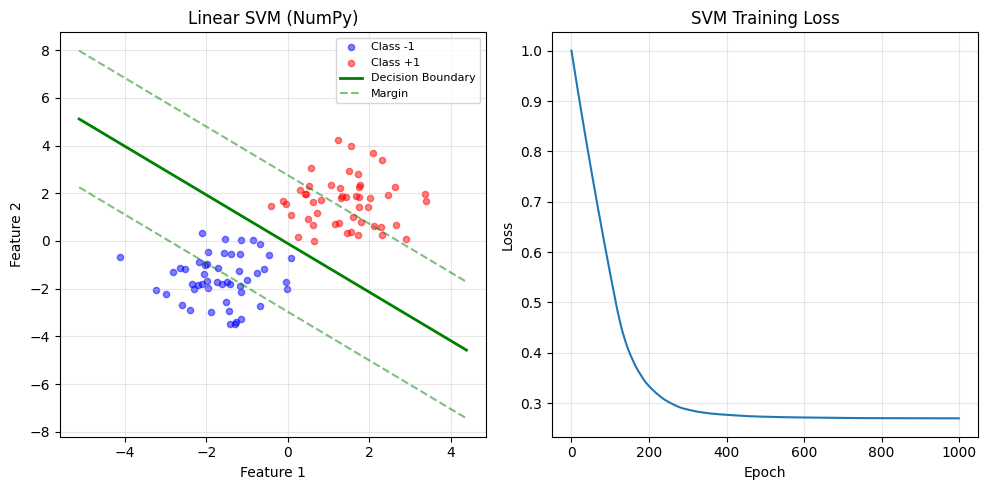

→ 圖表儲存至 plots/05_svm_linear.png


In [2]:
print("=" * 60)
print("Part A: 線性 SVM — 找到最大間隔的邊界")
print("=" * 60)

print("""
SVM 的優化目標：
  最小化: (1/2)||w||² + C × Σ max(0, 1 - yᵢ(w·xᵢ + b))
           ↑ 間隔最大化     ↑ Hinge Loss（分錯的懲罰）

  C 是正則化參數：
    C 大 → 不容許分錯 → 可能過擬合
    C 小 → 容許一些分錯 → 更平滑的邊界
""")

# --- 生成資料 ---
np.random.seed(42)
N = 100
X0 = np.random.randn(N // 2, 2) + np.array([-1.5, -1.5])
X1 = np.random.randn(N // 2, 2) + np.array([1.5, 1.5])
X = np.vstack([X0, X1])
y = np.array([-1] * (N // 2) + [1] * (N // 2))    # SVM 用 -1 和 +1

idx = np.random.permutation(N)
X, y = X[idx], y[idx]

# --- NumPy 手刻 (Hinge Loss + SGD) ---
class LinearSVM_Numpy:
    """用 Hinge Loss + 梯度下降實作的線性 SVM"""

    def __init__(self, C=1.0, lr=0.001, epochs=1000):
        self.C = C
        self.lr = lr
        self.epochs = epochs

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0.0
        self.loss_history = []

        for epoch in range(self.epochs):
            # 計算 scores
            scores = X @ self.w + self.b         # (N,)
            margins = y * scores                 # (N,)

            # Hinge Loss: max(0, 1 - y*(w·x + b))
            hinge_loss = np.maximum(0, 1 - margins)
            total_loss = 0.5 * np.dot(self.w, self.w) + self.C * np.mean(hinge_loss)
            self.loss_history.append(total_loss)

            # 梯度
            # 對於 margin < 1 的樣本（分錯或在間隔內）
            mask = (margins < 1).astype(float)      # 1 if violated, 0 if ok

            dw = self.w - self.C * np.mean((mask * y)[:, None] * X, axis=0)
            db = -self.C * np.mean(mask * y)

            self.w -= self.lr * dw
            self.b -= self.lr * db

            if epoch % 200 == 0:
                acc = np.mean(np.sign(scores) == y)
                print(f"  Epoch {epoch:4d}: Loss={total_loss:.4f}, Acc={acc:.2%}")

    def predict(self, X):
        return np.sign(X @ self.w + self.b)


svm = LinearSVM_Numpy(C=1.0, lr=0.001, epochs=1000)
svm.fit(X, y)

y_pred = svm.predict(X)
print(f"\n手刻 SVM 準確率: {np.mean(y_pred == y):.2%}")

# 畫結果
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.scatter(X[y == -1, 0], X[y == -1, 1], c='blue', alpha=0.5, s=20, label='Class -1')
plt.scatter(X[y == 1, 0], X[y == 1, 1], c='red', alpha=0.5, s=20, label='Class +1')

# 決策邊界和間隔
x_line = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 100)
if svm.w[1] != 0:
    y_boundary = -(svm.w[0] * x_line + svm.b) / svm.w[1]
    y_margin_pos = -(svm.w[0] * x_line + svm.b - 1) / svm.w[1]
    y_margin_neg = -(svm.w[0] * x_line + svm.b + 1) / svm.w[1]
    plt.plot(x_line, y_boundary, 'g-', linewidth=2, label='Decision Boundary')
    plt.plot(x_line, y_margin_pos, 'g--', alpha=0.5, label='Margin')
    plt.plot(x_line, y_margin_neg, 'g--', alpha=0.5)

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Linear SVM (NumPy)')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(svm.loss_history)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('SVM Training Loss')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('phase-1-ml-basics/plots/05_svm_linear.png', dpi=100)
plt.show()
print("→ 圖表儲存至 plots/05_svm_linear.png")

## Part B: Kernel Trick — 非線性分類


Part B: Kernel Trick

問題：如果資料不是線性可分的怎麼辦？

  例：「甜甜圈」形狀的資料，裡面是一類，外面是一類
  → 在 2D 中畫不出一條直線分開它們

Kernel Trick 的解法：
  把資料映射到更高維的空間，在高維中找線性邊界

  常見 Kernel：
  - Linear:     K(x, y) = xᵀy         （就是線性 SVM）
  - Polynomial: K(x, y) = (xᵀy + c)^d  （多項式映射）
  - RBF/Gaussian: K(x, y) = exp(-γ||x-y||²)  （最常用）



環形資料: (200, 2), 類別: [0 1]


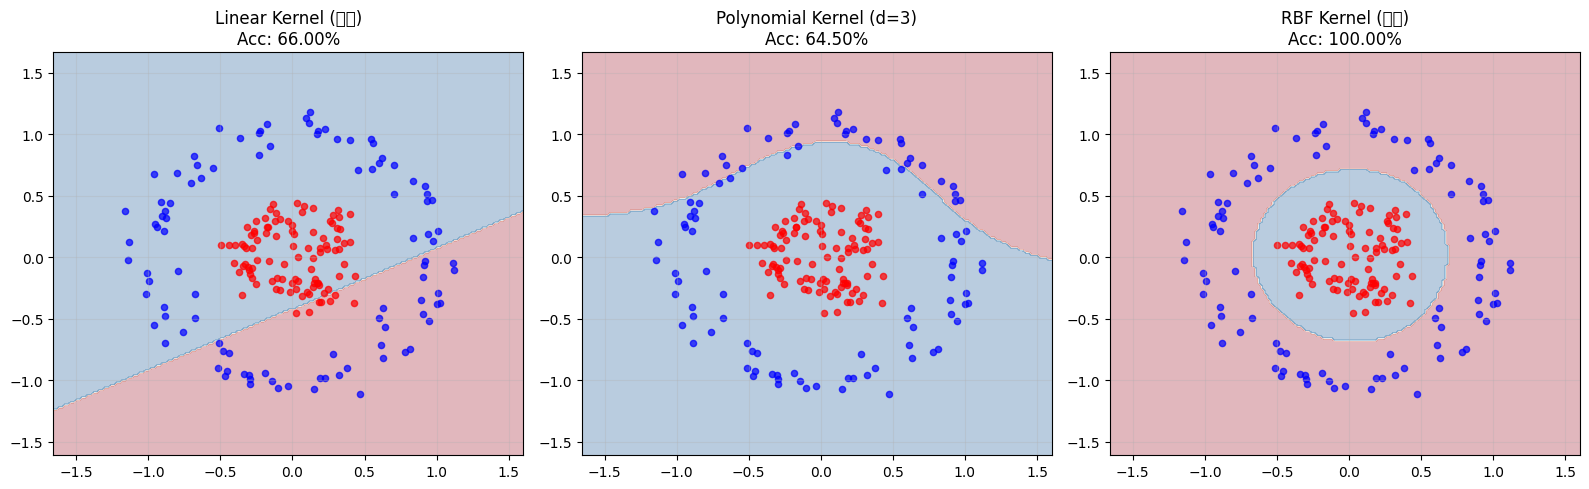

→ 圖表儲存至 plots/05_svm_kernels.png


In [3]:
print("\n" + "=" * 60)
print("Part B: Kernel Trick")
print("=" * 60)

print("""
問題：如果資料不是線性可分的怎麼辦？

  例：「甜甜圈」形狀的資料，裡面是一類，外面是一類
  → 在 2D 中畫不出一條直線分開它們

Kernel Trick 的解法：
  把資料映射到更高維的空間，在高維中找線性邊界

  常見 Kernel：
  - Linear:     K(x, y) = xᵀy         （就是線性 SVM）
  - Polynomial: K(x, y) = (xᵀy + c)^d  （多項式映射）
  - RBF/Gaussian: K(x, y) = exp(-γ||x-y||²)  （最常用）
""")

# 生成環形資料（線性不可分）
from sklearn.datasets import make_circles
X_circle, y_circle = make_circles(n_samples=200, noise=0.1, factor=0.3, random_state=42)

print(f"環形資料: {X_circle.shape}, 類別: {np.unique(y_circle)}")

# 展示為什麼線性不行，RBF 可以
from sklearn.svm import SVC

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

kernels = ['linear', 'poly', 'rbf']
titles = ['Linear Kernel (失敗)', 'Polynomial Kernel (d=3)', 'RBF Kernel (成功)']

for ax, kernel, title in zip(axes, kernels, titles):
    clf = SVC(kernel=kernel, degree=3, gamma='auto')
    clf.fit(X_circle, y_circle)
    acc = clf.score(X_circle, y_circle)

    # 畫決策邊界
    h = 0.02
    x_min, x_max = X_circle[:, 0].min() - 0.5, X_circle[:, 0].max() + 0.5
    y_min, y_max = X_circle[:, 1].min() - 0.5, X_circle[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = clf.predict(np.column_stack([xx.ravel(), yy.ravel()])).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    ax.scatter(X_circle[y_circle == 0, 0], X_circle[y_circle == 0, 1],
               c='blue', s=20, alpha=0.7)
    ax.scatter(X_circle[y_circle == 1, 0], X_circle[y_circle == 1, 1],
               c='red', s=20, alpha=0.7)
    ax.set_title(f'{title}\nAcc: {acc:.2%}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('phase-1-ml-basics/plots/05_svm_kernels.png', dpi=100)
plt.show()
print("→ 圖表儲存至 plots/05_svm_kernels.png")

## Part C: Scikit-learn 完整範例

In [4]:
print("\n" + "=" * 60)
print("Part C: Scikit-learn SVM")
print("=" * 60)

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.2, random_state=42
)

# SVM 對特徵尺度敏感，必須標準化！
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# 比較不同 kernel
print(f"{'Kernel':>12s}  {'Accuracy':>10s}  {'Support Vectors':>16s}")
print("-" * 45)

for kernel in ['linear', 'poly', 'rbf']:
    clf = SVC(kernel=kernel, random_state=42)
    clf.fit(X_train_s, y_train)
    acc = clf.score(X_test_s, y_test)
    n_sv = clf.n_support_.sum()
    print(f"{kernel:>12s}  {acc:10.2%}  {n_sv:>16d}")

# C 參數的影響
print(f"\nRBF Kernel, 不同 C 值:")
for C in [0.01, 0.1, 1, 10, 100]:
    clf = SVC(kernel='rbf', C=C, random_state=42)
    clf.fit(X_train_s, y_train)
    train_acc = clf.score(X_train_s, y_train)
    test_acc = clf.score(X_test_s, y_test)
    print(f"  C={C:6.2f}  Train: {train_acc:.2%}  Test: {test_acc:.2%}  "
          f"SVs: {clf.n_support_.sum()}")


Part C: Scikit-learn SVM
      Kernel    Accuracy   Support Vectors
---------------------------------------------
      linear      96.67%                26
        poly      96.67%                46
         rbf     100.00%                46

RBF Kernel, 不同 C 值:
  C=  0.01  Train: 34.17%  Test: 30.00%  SVs: 120
  C=  0.10  Train: 88.33%  Test: 96.67%  SVs: 96
  C=  1.00  Train: 96.67%  Test: 100.00%  SVs: 46
  C= 10.00  Train: 98.33%  Test: 96.67%  SVs: 31
  C=100.00  Train: 98.33%  Test: 100.00%  SVs: 26


## 小結

In [5]:
print("\n" + "=" * 60)
print("小結")
print("=" * 60)
print("""
SVM 教會你的核心概念：

  概念                對應到深度學習
  ───────────────────────────────────────────────
  最大間隔            →  正則化的概念（不只要分對，還要有信心）
  Hinge Loss         →  損失函數的另一種選擇
  Kernel Trick       →  神經網路的隱藏層也在做「特徵映射」
  C (正則化參數)      →  正則化強度 (weight decay)
  特徵標準化必要性     →  深度學習也需要 Normalization

關鍵理解：
  SVM 用 Kernel 顯式映射到高維
  神經網路用多層非線性變換隱式地做同樣的事

sklearn 速查：
  from sklearn.svm import SVC
  clf = SVC(kernel='rbf', C=1.0, gamma='scale')
  clf.fit(X_train, y_train)     # 記得先 StandardScaler！
  clf.predict(X_test)
  clf.n_support_                # 支持向量數量

下一步：06_unsupervised.py — 非監督式學習
""")


小結

SVM 教會你的核心概念：

  概念                對應到深度學習
  ───────────────────────────────────────────────
  最大間隔            →  正則化的概念（不只要分對，還要有信心）
  Hinge Loss         →  損失函數的另一種選擇
  Kernel Trick       →  神經網路的隱藏層也在做「特徵映射」
  C (正則化參數)      →  正則化強度 (weight decay)
  特徵標準化必要性     →  深度學習也需要 Normalization

關鍵理解：
  SVM 用 Kernel 顯式映射到高維
  神經網路用多層非線性變換隱式地做同樣的事

sklearn 速查：
  from sklearn.svm import SVC
  clf = SVC(kernel='rbf', C=1.0, gamma='scale')
  clf.fit(X_train, y_train)     # 記得先 StandardScaler！
  clf.predict(X_test)
  clf.n_support_                # 支持向量數量

下一步：06_unsupervised.py — 非監督式學習

